In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import LBFGS
import matplotlib.pyplot as plt
import random
import copy
import urllib.request
import scipy.io
from tqdm import tqdm

In [2]:
seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [3]:
def get_data(x_range, y_range, x_num, y_num):
    x = np.linspace(x_range[0], x_range[1], x_num)
    t = np.linspace(y_range[0], y_range[1], y_num)
    x_mesh, t_mesh = np.meshgrid(x, t)
    data = np.concatenate((np.expand_dims(x_mesh, -1), np.expand_dims(t_mesh, -1)), axis=-1)
    b_left = data[0, :, :]
    b_right = data[-1, :, :]
    b_upper = data[:, -1, :]
    b_lower = data[:, 0, :]
    res = data.reshape(-1, 2)
    return res, b_left, b_right, b_upper, b_lower


def make_time_sequence(src, num_step=5, step=1e-4):
    dim = num_step
    src = np.repeat(np.expand_dims(src, axis=1), dim, axis=1)
    for i in range(num_step):
        src[:, i, -1] += step * i
    return src


def get_n_params(model):
    pp = 0
    for p in list(model.parameters()):
        nn_ = 1
        for s in list(p.size()):
            nn_ = nn_ * s
        pp += nn_
    return pp


def get_clones(module, N):
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])


def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)


def rel_errors(pred, true):
    rmae = np.sum(np.abs(pred - true)) / np.sum(np.abs(true))
    rrmse = np.sqrt(np.sum((pred - true) ** 2) / np.sum(true ** 2))
    return rmae, rrmse

In [4]:
class WaveAct(nn.Module):
    def __init__(self):
        super(WaveAct, self).__init__()
        self.w1 = nn.Parameter(torch.ones(1), requires_grad=True)
        self.w2 = nn.Parameter(torch.ones(1), requires_grad=True)

    def forward(self, x):
        return self.w1 * torch.sin(x) + self.w2 * torch.cos(x)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=256):
        super(FeedForward, self).__init__()
        self.linear = nn.Sequential(*[
            nn.Linear(d_model, d_ff),
            WaveAct(),
            nn.Linear(d_ff, d_ff),
            WaveAct(),
            nn.Linear(d_ff, d_model)
        ])

    def forward(self, x):
        return self.linear(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, heads):
        super(EncoderLayer, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=heads, batch_first=True)
        self.ff = FeedForward(d_model)
        self.act1 = WaveAct()
        self.act2 = WaveAct()

    def forward(self, x):
        x2 = self.act1(x)
        x = x + self.attn(x2, x2, x2)[0]
        x2 = self.act2(x)
        x = x + self.ff(x2)
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, heads):
        super(DecoderLayer, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=heads, batch_first=True)
        self.ff = FeedForward(d_model)
        self.act1 = WaveAct()
        self.act2 = WaveAct()

    def forward(self, x, e_outputs):
        x2 = self.act1(x)
        x = x + self.attn(x2, e_outputs, e_outputs)[0]
        x2 = self.act2(x)
        x = x + self.ff(x2)
        return x


class Encoder(nn.Module):
    def __init__(self, d_model, N, heads):
        super(Encoder, self).__init__()
        self.N = N
        self.layers = get_clones(EncoderLayer(d_model, heads), N)
        self.act = WaveAct()

    def forward(self, x):
        for i in range(self.N):
            x = self.layers[i](x)
        return self.act(x)


class Decoder(nn.Module):
    def __init__(self, d_model, N, heads):
        super(Decoder, self).__init__()
        self.N = N
        self.layers = get_clones(DecoderLayer(d_model, heads), N)
        self.act = WaveAct()

    def forward(self, x, e_outputs):
        for i in range(self.N):
            x = self.layers[i](x, e_outputs)
        return self.act(x)


class PINNsformer(nn.Module):
    def __init__(self, d_out, d_model, d_hidden, N, heads):
        super(PINNsformer, self).__init__()
        self.linear_emb = nn.Linear(2, d_model)
        self.encoder = Encoder(d_model, N, heads)
        self.decoder = Decoder(d_model, N, heads)
        self.linear_out = nn.Sequential(*[
            nn.Linear(d_model, d_hidden),
            WaveAct(),
            nn.Linear(d_hidden, d_hidden),
            WaveAct(),
            nn.Linear(d_hidden, d_out)
        ])

    def forward(self, x, t):
        src = torch.cat((x, t), dim=-1)
        src = self.linear_emb(src)
        e_outputs = self.encoder(src)
        d_output = self.decoder(src, e_outputs)
        output = self.linear_out(d_output)
        return output

In [5]:
class PINNs(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layer):
        super(PINNs, self).__init__()
        layers = []
        for i in range(num_layer - 1):
            if i == 0:
                layers.append(nn.Linear(in_features=in_dim, out_features=hidden_dim))
                layers.append(nn.Tanh())
            else:
                layers.append(nn.Linear(in_features=hidden_dim, out_features=hidden_dim))
                layers.append(nn.Tanh())
        layers.append(nn.Linear(in_features=hidden_dim, out_features=out_dim))
        self.linear = nn.Sequential(*layers)

    def forward(self, x, t):
        src = torch.cat((x, t), dim=-1)
        return self.linear(src)

In [ ]:
url = "https://raw.githubusercontent.com/maziarraissi/PINNs/master/main/Data/KdV.mat"
urllib.request.urlretrieve(url, "KdV.mat")

mat_data = scipy.io.loadmat("KdV.mat")
x_ref = mat_data['x'].flatten()     
t_ref = mat_data['tt'].flatten()     
u_ref = mat_data['uu']               

print('x_ref:', x_ref.shape, ' t_ref:', t_ref.shape, ' u_ref:', u_ref.shape)

x_ref: (512,)  t_ref: (201,)  u_ref: (512, 201)


In [ ]:
nu_coeff = 0.0025
x_range, t_range = [-1, 1], [0, 1]
Nx, Nt = 51, 51

res, b_left, b_right, b_upper, b_lower = get_data(x_range, t_range, Nx, Nt)

In [8]:
def to_tensor_pw(arr):
    return torch.tensor(arr, dtype=torch.float32, requires_grad=True).to(device)

res_pw = to_tensor_pw(res)
b_left_pw = to_tensor_pw(b_left)
b_upper_pw = to_tensor_pw(b_upper)
b_lower_pw = to_tensor_pw(b_lower)

x_res_pw, t_res_pw = res_pw[:, 0:1], res_pw[:, 1:2]
x_left_pw, t_left_pw = b_left_pw[:, 0:1], b_left_pw[:, 1:2]
x_upper_pw, t_upper_pw = b_upper_pw[:, 0:1], b_upper_pw[:, 1:2]
x_lower_pw, t_lower_pw = b_lower_pw[:, 0:1], b_lower_pw[:, 1:2]

In [9]:
k, dt_step = 5, 1e-4

def to_tensor_seq(arr):
    seq = make_time_sequence(arr, num_step=k, step=dt_step)
    return torch.tensor(seq, dtype=torch.float32, requires_grad=True).to(device)

res_seq = to_tensor_seq(res)
b_left_seq = to_tensor_seq(b_left)
b_upper_seq = to_tensor_seq(b_upper)
b_lower_seq = to_tensor_seq(b_lower)

x_res_seq, t_res_seq = res_seq[:, :, 0:1], res_seq[:, :, 1:2]
x_left_seq, t_left_seq = b_left_seq[:, :, 0:1], b_left_seq[:, :, 1:2]
x_upper_seq, t_upper_seq = b_upper_seq[:, :, 0:1], b_upper_seq[:, :, 1:2]
x_lower_seq, t_lower_seq = b_lower_seq[:, :, 0:1], b_lower_seq[:, :, 1:2]

In [10]:
n_iter = 500

model_pinn = PINNs(in_dim=2, hidden_dim=512, out_dim=1, num_layer=4).to(device)
model_pinn.apply(init_weights)
optim_pinn = LBFGS(model_pinn.parameters(), line_search_fn='strong_wolfe')

loss_track_pinn = []

for i in tqdm(range(n_iter), desc='Training PINN baseline'):
    def closure():
        pred_res = model_pinn(x_res_pw, t_res_pw)
        pred_left = model_pinn(x_left_pw, t_left_pw)
        pred_upper = model_pinn(x_upper_pw, t_upper_pw)
        pred_lower = model_pinn(x_lower_pw, t_lower_pw)

        u_x = torch.autograd.grad(pred_res, x_res_pw, grad_outputs=torch.ones_like(pred_res), retain_graph=True, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_res_pw, grad_outputs=torch.ones_like(u_x), retain_graph=True, create_graph=True)[0]
        u_xxx = torch.autograd.grad(u_xx, x_res_pw, grad_outputs=torch.ones_like(u_xx), retain_graph=True, create_graph=True)[0]
        u_t = torch.autograd.grad(pred_res, t_res_pw, grad_outputs=torch.ones_like(pred_res), retain_graph=True, create_graph=True)[0]

        loss_res = torch.mean((u_t + pred_res * u_x + nu_coeff * u_xxx) ** 2)

        u_x_upper = torch.autograd.grad(pred_upper, x_upper_pw, grad_outputs=torch.ones_like(pred_upper), retain_graph=True, create_graph=True)[0]
        u_x_lower = torch.autograd.grad(pred_lower, x_lower_pw, grad_outputs=torch.ones_like(pred_lower), retain_graph=True, create_graph=True)[0]
        loss_bc = torch.mean((pred_upper - pred_lower) ** 2) + torch.mean((u_x_upper - u_x_lower) ** 2)

        loss_ic = torch.mean((pred_left[:, 0] - torch.cos(np.pi * x_left_pw[:, 0])) ** 2)

        loss_track_pinn.append([loss_res.item(), loss_bc.item(), loss_ic.item()])

        loss = loss_res + loss_bc + loss_ic
        optim_pinn.zero_grad()
        loss.backward()
        return loss

    optim_pinn.step(closure)

print('PINN  -> Res: {:.4e}, BC: {:.4e}, IC: {:.4e}'.format(*loss_track_pinn[-1]))

Training PINN baseline:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Training PINN baseline: 100%|██████████| 500/500 [10:38<00:00,  1.28s/it]

PINN  -> Res: 1.5461e-03, BC: 3.7086e-05, IC: 1.0068e-03


In [11]:
model_pf = PINNsformer(d_out=1, d_hidden=512, d_model=32, N=1, heads=2).to(device)
model_pf.apply(init_weights)
optim_pf = LBFGS(model_pf.parameters(), line_search_fn='strong_wolfe')

loss_track_pf = []

for i in tqdm(range(n_iter), desc='Training PINNsFormer'):
    def closure():
        pred_res = model_pf(x_res_seq, t_res_seq)
        pred_left = model_pf(x_left_seq, t_left_seq)
        pred_upper = model_pf(x_upper_seq, t_upper_seq)
        pred_lower = model_pf(x_lower_seq, t_lower_seq)

        u_x = torch.autograd.grad(pred_res, x_res_seq, grad_outputs=torch.ones_like(pred_res), retain_graph=True, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_res_seq, grad_outputs=torch.ones_like(u_x), retain_graph=True, create_graph=True)[0]
        u_xxx = torch.autograd.grad(u_xx, x_res_seq, grad_outputs=torch.ones_like(u_xx), retain_graph=True, create_graph=True)[0]
        u_t = torch.autograd.grad(pred_res, t_res_seq, grad_outputs=torch.ones_like(pred_res), retain_graph=True, create_graph=True)[0]

        loss_res = torch.mean((u_t + pred_res * u_x + nu_coeff * u_xxx) ** 2)

        u_x_upper = torch.autograd.grad(pred_upper, x_upper_seq, grad_outputs=torch.ones_like(pred_upper), retain_graph=True, create_graph=True)[0]
        u_x_lower = torch.autograd.grad(pred_lower, x_lower_seq, grad_outputs=torch.ones_like(pred_lower), retain_graph=True, create_graph=True)[0]
        loss_bc = torch.mean((pred_upper - pred_lower) ** 2) + torch.mean((u_x_upper - u_x_lower) ** 2)

        loss_ic = torch.mean((pred_left[:, 0] - torch.cos(np.pi * x_left_seq[:, 0])) ** 2)

        loss_track_pf.append([loss_res.item(), loss_bc.item(), loss_ic.item()])

        loss = loss_res + loss_bc + loss_ic
        optim_pf.zero_grad()
        loss.backward()
        return loss

    optim_pf.step(closure)

print('PINNsFormer -> Res: {:.4e}, BC: {:.4e}, IC: {:.4e}'.format(*loss_track_pf[-1]))

Training PINNsFormer: 100%|██████████| 500/500 [1:48:52<00:00, 13.06s/it]

PINNsFormer -> Res: 8.8273e-05, BC: 4.4972e-06, IC: 4.6642e-05


In [12]:
X_ref, T_ref = np.meshgrid(x_ref, t_ref, indexing='ij')   # shape (512, 201), matches u_ref
test_points = np.concatenate([X_ref.reshape(-1, 1), T_ref.reshape(-1, 1)], axis=1)

test_pw = torch.tensor(test_points, dtype=torch.float32).to(device)
with torch.no_grad():
    pred_pinn = model_pinn(test_pw[:, 0:1], test_pw[:, 1:2]).cpu().numpy().reshape(X_ref.shape)

test_seq = make_time_sequence(test_points, num_step=k, step=dt_step)
test_seq_t = torch.tensor(test_seq, dtype=torch.float32).to(device)
with torch.no_grad():
    pred_pf = model_pf(test_seq_t[:, :, 0:1], test_seq_t[:, :, 1:2])[:, 0, 0].cpu().numpy().reshape(X_ref.shape)

rmae_pinn, rrmse_pinn = rel_errors(pred_pinn, u_ref)
rmae_pf, rrmse_pf = rel_errors(pred_pf, u_ref)

print(f"{'Model':<15}{'rMAE':>10}{'rRMSE':>10}")
print(f"{'PINNs':<15}{rmae_pinn:>10.4f}{rrmse_pinn:>10.4f}")
print(f"{'PINNsFormer':<15}{rmae_pf:>10.4f}{rrmse_pf:>10.4f}")

Model                rMAE     rRMSE
PINNs              0.0820    0.0857
PINNsFormer        0.0184    0.0181


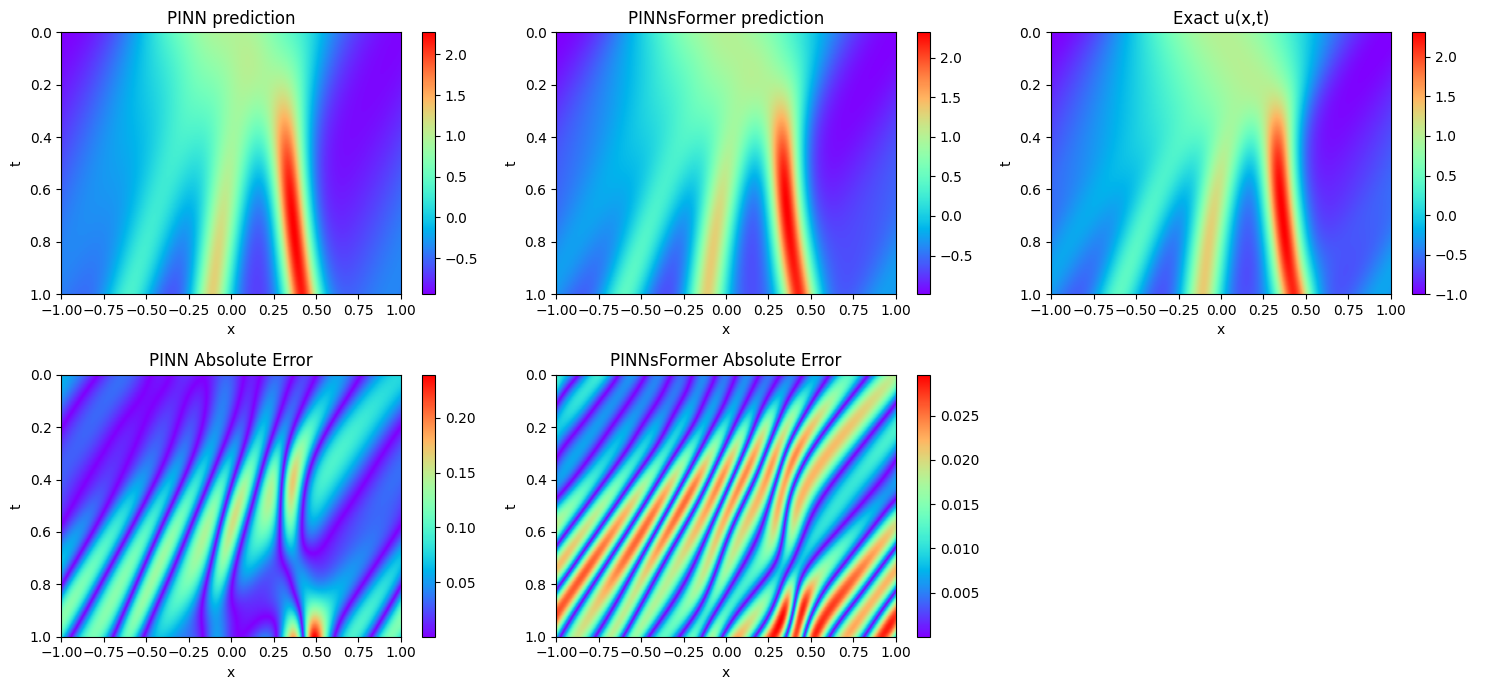

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

im0 = axes[0,0].imshow(pred_pinn.T, extent=[-1,1,1,0], aspect='auto', cmap='rainbow')
axes[0,0].set_title('PINN prediction'); axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('t')
plt.colorbar(im0, ax=axes[0,0])

im1 = axes[0,1].imshow(pred_pf.T, extent=[-1,1,1,0], aspect='auto', cmap='rainbow')
axes[0,1].set_title('PINNsFormer prediction'); axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('t')
plt.colorbar(im1, ax=axes[0,1])

im2 = axes[0,2].imshow(u_ref.T, extent=[-1,1,1,0], aspect='auto', cmap='rainbow')
axes[0,2].set_title('Exact u(x,t)'); axes[0,2].set_xlabel('x'); axes[0,2].set_ylabel('t')
plt.colorbar(im2, ax=axes[0,2])

im3 = axes[1,0].imshow(np.abs(pred_pinn-u_ref).T, extent=[-1,1,1,0], aspect='auto', cmap='rainbow')
axes[1,0].set_title('PINN Absolute Error'); axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('t')
plt.colorbar(im3, ax=axes[1,0])

im4 = axes[1,1].imshow(np.abs(pred_pf-u_ref).T, extent=[-1,1,1,0], aspect='auto', cmap='rainbow')
axes[1,1].set_title('PINNsFormer Absolute Error'); axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('t')
plt.colorbar(im4, ax=axes[1,1])

axes[1,2].axis('off')

plt.tight_layout()
plt.savefig('./kdv_results.png', dpi=150)
plt.show()